In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = {
    "duration": [7, 2, 10, 0, 5, 3, 12, 1, 8, 4],
    "src_bytes": [100, 200, 5000, 50, 120, 300, 7000, 80, 150, 90],
    "dst_bytes": [50, 120, 80, 8000, 10, 40, 60, 1000, 200, 150],
    "protocol_type": ["TCP", "TCP", "UDP", "TCP", "ICMP", "UDP", "TCP", "ICMP", "TCP", "UDP"],
    "flag": ["SF", "SF", "S0", "REJ", "SF", "S0", "S0", "SF", "SF", "SF"],
    "label": ["normal", "normal", "attack", "attack", "normal", "attack", "attack", "attack", "normal", "normal"]
}

In [4]:
df = pd.DataFrame(data)
df

,duration,src_bytes,dst_bytes,protocol_type,flag,label
0,7,100,50,TCP,SF,normal
1,2,200,120,TCP,SF,normal
2,10,5000,80,UDP,S0,attack
3,0,50,8000,TCP,REJ,attack
4,5,120,10,ICMP,SF,normal
5,3,300,40,UDP,S0,attack
6,12,7000,60,TCP,S0,attack
7,1,80,1000,ICMP,SF,attack
8,8,150,200,TCP,SF,normal
9,4,90,150,UDP,SF,normal


In [5]:
print("Data Types:\n")
print(df.dtypes)

print("\nCategorical Columns:", df.select_dtypes(include=['object']).columns.tolist())
print("Numerical Columns:", df.select_dtypes(include=['int64', 'float64']).columns.tolist())


Data Types:

duration          int64
src_bytes         int64
dst_bytes         int64
protocol_type    object
flag             object
label            object
dtype: object

Categorical Columns: ['protocol_type', 'flag', 'label']
Numerical Columns: ['duration', 'src_bytes', 'dst_bytes']


In [6]:
# Mean, Median, Std for numerical features
stats = df[["duration", "src_bytes", "dst_bytes"]].agg(['mean', 'median', 'std'])
stats


,duration,src_bytes,dst_bytes
mean,5.200000,1309.000000,971.00000
median,4.500000,135.000000,100.00000
std,3.966527,2517.915584,2486.91442


In [7]:
print("Max values:")
print(df[["duration", "src_bytes", "dst_bytes"]].max())

print("\nMin values:")
print(df[["duration", "src_bytes", "dst_bytes"]].min())



Max values:
duration       12
src_bytes    7000
dst_bytes    8000
dtype: int64

Min values:
duration      0
src_bytes    50
dst_bytes    10
dtype: int64


In [9]:
import seaborn as sns
plt.style.use("default")


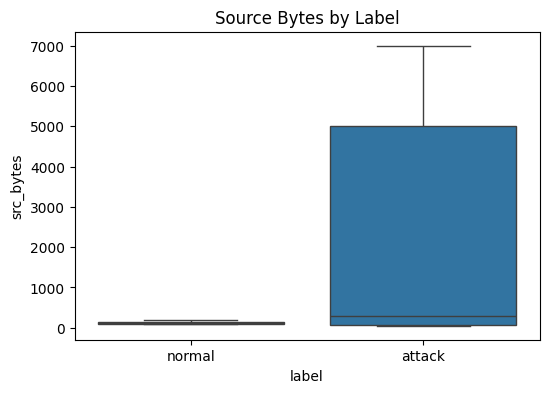

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x="label", y="src_bytes", data=df)
plt.title("Source Bytes by Label")
plt.show()


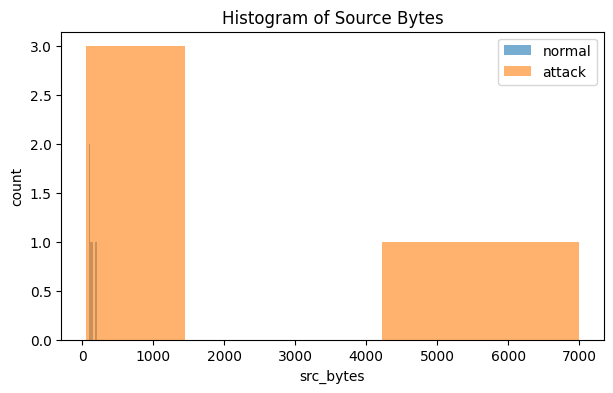

In [11]:
plt.figure(figsize=(7,4))

for label in ["normal", "attack"]:
    subset = df[df["label"] == label]
    plt.hist(subset["src_bytes"], alpha=0.6, bins=5, label=label)

plt.title("Histogram of Source Bytes")
plt.xlabel("src_bytes")
plt.ylabel("count")
plt.legend()
plt.show()


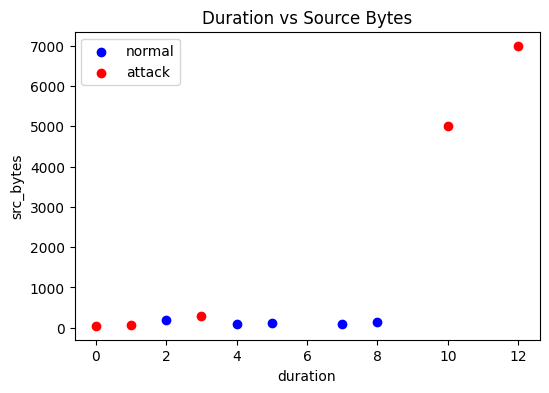

In [12]:
plt.figure(figsize=(6,4))

colors = {"normal": "blue", "attack": "red"}

for label in ["normal", "attack"]:
    subset = df[df["label"] == label]
    plt.scatter(subset["duration"], subset["src_bytes"], 
                c=colors[label], label=label)

plt.title("Duration vs Source Bytes")
plt.xlabel("duration")
plt.ylabel("src_bytes")
plt.legend()
plt.show()


<Figure size 700x400 with 0 Axes>

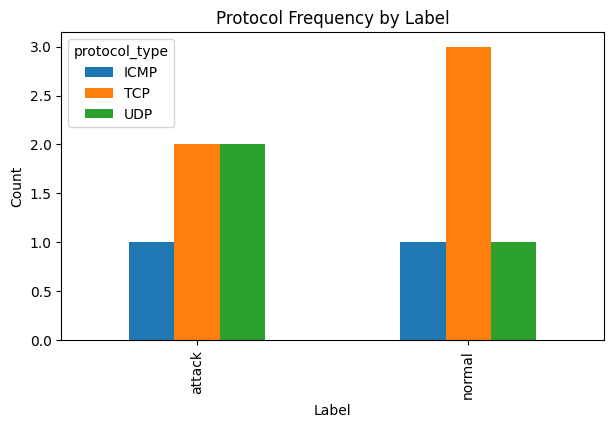

In [13]:
plt.figure(figsize=(7,4))

protocol_counts = df.groupby(["label", "protocol_type"]).size().unstack()
protocol_counts.plot(kind="bar", figsize=(7,4))

plt.title("Protocol Frequency by Label")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()
